## **IBM Quantum Hardware**

No QPU allocation needed: `local=True` runs the identical circuits on the calibration twin, and the campaign's raw counts are archived under `paper/hw_run/`.

### **One Executor, Three Targets**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qconflib import problem_1d, Executor, BatchedExpectation, statevector, measure_map

n, depth = 5, 4
prob = problem_1d(n)

ideal = Executor(seed=111)
emul = Executor(noise_from='sherbrooke', seed=111)
twin = Executor(hardware='ibm_kingston', local=True, seed=111)

for tag, ex in [('ideal    ', ideal), ('emulated ', emul), ('hardware ', twin)]:
    print(f"{tag} backend_name = {ex.backend_name!r:<28} noisy = {ex.noisy}")

ideal     backend_name = 'ideal statevector (GPU)'    noisy = False
emulated  backend_name = 'fake_sherbrooke'            noisy = True
hardware  backend_name = 'ibm_kingston'               noisy = True


### **Transpiling Against a Real Device**

In [2]:
theta = np.loadtxt('paper/data/prod/r_1d_N32_params_classical.csv', delimiter=',')
psi = statevector(theta, n, depth)
exact = float(psi @ prob.M @ psi)
print(f"using the noiselessly trained parameters; exact <H> = {exact:.5f} "
      f"(lam_min {prob.lam_min:.5f})")

bx_hw = BatchedExpectation(prob, 'SD', depth, twin)
for j, t in enumerate(bx_hw.templates):
    n2 = sum(1 for i in t.data if i.operation.num_qubits == 2)
    print(f"  SD circuit {j}: {t.num_qubits} device qubits, depth {t.depth():>3}, "
          f"{n2:>3} two-qubit gates, measured physical qubits {measure_map(t)}")

using the noiselessly trained parameters; exact <H> = 0.00906 (lam_min 0.00906)
  SD circuit 0: 156 device qubits, depth  51,  20 two-qubit gates, measured physical qubits [88, 89, 90, 91, 98]
  SD circuit 1: 156 device qubits, depth  48,  19 two-qubit gates, measured physical qubits [88, 89, 90, 91]
  SD circuit 2: 156 device qubits, depth  47,  18 two-qubit gates, measured physical qubits [144, 143, 142]
  SD circuit 3: 156 device qubits, depth  47,  17 two-qubit gates, measured physical qubits [20, 21]
  SD circuit 4: 156 device qubits, depth  47,  16 two-qubit gates, measured physical qubits [21]


logical/ideal transpilation depth : 18
real-device transpilation depth   : 51

the device circuit, first 40 layers:


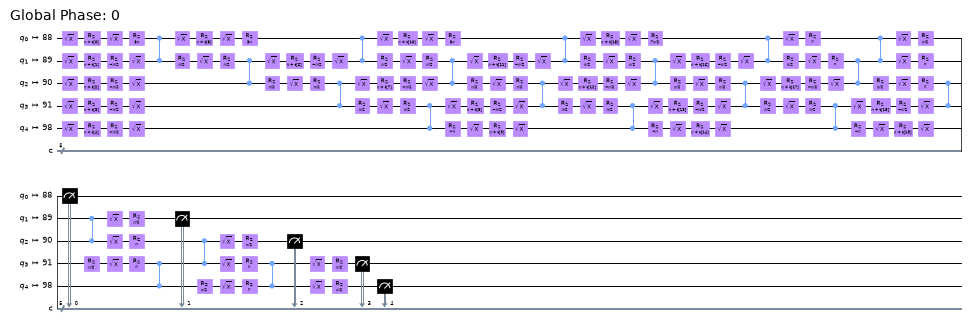

In [3]:
# the same logical circuit, transpiled for the line-connectivity emulator vs the real device
logical_depth = BatchedExpectation(prob, 'SD', depth, Executor(seed=1)).templates[0].depth()
print(f"logical/ideal transpilation depth : {logical_depth}")
print(f"real-device transpilation depth   : {bx_hw.templates[0].depth()}")
print("\nthe device circuit, first 40 layers:")
bx_hw.templates[0].draw('mpl', style='clifford', idle_wires=False, fold=40, scale=0.35)

### **Measuring on the Twin**

In [4]:
import time
shots = 8192
t0 = time.perf_counter()
readings = {}
for m in ('SD', 'PO', 'FD'):
    bx = BatchedExpectation(prob, m, depth, twin)
    readings[m] = bx.value(theta, shots)
print(f"[{time.perf_counter()-t0:.0f} s]\n")
print(f"exact <H> = {exact:.5f}\n")
for m, v in readings.items():
    print(f"  {m}: {v:>8.4f}   bias {v-exact:>+8.4f}")

[21 s]

exact <H> = 0.00906

  SD:   0.0702   bias  +0.0611
  PO:   0.2406   bias  +0.2315
  FD:   0.2253   bias  +0.2163


### **Submitting to the Device**

Drop `local=True` and save credentials once. Not executed here.

In [5]:
# NOT EXECUTED - requires an IBM Quantum account and consumes QPU time.
submit_code = '''
from qconflib import Executor, BatchedExpectation

qpu = Executor(hardware='ibm_kingston')          # live backend, no local=True
bx = BatchedExpectation(prob, 'SD', depth, qpu)

job = qpu.submit(bx._bind(theta), shots=8192)    # returns immediately
print('job id', job.job_id())                    # archive this alongside the circuits

# ... later, in a separate session ...
counts = Executor.fetch(qpu.job('<archived job id>'))
value = bx._decode(counts, 8192)
'''
print(submit_code)


from qconflib import Executor, BatchedExpectation

qpu = Executor(hardware='ibm_kingston')          # live backend, no local=True
bx = BatchedExpectation(prob, 'SD', depth, qpu)

job = qpu.submit(bx._bind(theta), shots=8192)    # returns immediately
print('job id', job.job_id())                    # archive this alongside the circuits

# ... later, in a separate session ...
counts = Executor.fetch(qpu.job('<archived job id>'))
value = bx._decode(counts, 8192)



### **The Campaign**

Eight jobs on `ibm_kingston` (Heron r2) inside one ten-minute allocation.

In [6]:
import json, os
H = os.path.join('paper', 'hw_run')
b = json.load(open(f'{H}/blockB_results.json'))

print(f"exact <M> at the trained parameters: {b['exact']:.5f}\n")
print(f"{'':>6}{'device':>10}{'device+RO':>12}{'twin':>10}{'twin+RO':>10}")
for m in ('SD', 'PO', 'FD'):
    print(f"{m:>6}{b['hw_raw'][m]:>10.4f}{b['hw_ro'][m]:>12.4f}"
          f"{b['twin_raw'][m]:>10.4f}{b['twin_ro'][m]:>10.4f}")
print(f"\nselected qubits have readout errors "
      f"{min(b['e0'].values()):.3f} to {max(b['e0'].values()):.3f}: "
      f"readout correction is nearly free but also nearly gainless on this generation")

exact <M> at the trained parameters: 0.00906

          device   device+RO      twin   twin+RO
    SD    0.1425      0.1303    0.1024    0.0436
    PO    0.5887      0.5834    0.2911    0.2544
    FD    0.6089      0.6249    1.9873    1.9844

selected qubits have readout errors 0.000 to 0.011: readout correction is nearly free but also nearly gainless on this generation


### **Emulator Bracket**

The Heron twin is optimistic, the Eagle snapshot pessimistic, and the device sits between them in every configuration.

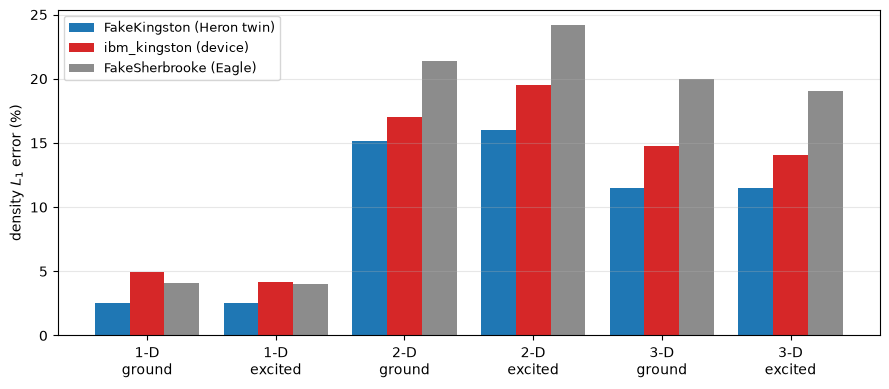

In [7]:
rdef = json.load(open(f'{H}/blockDEF_results.json'))
rsh = json.load(open(f'{H}/sherbrooke_density_l1.json'))

groups = ['1-D\nground', '1-D\nexcited', '2-D\nground', '2-D\nexcited', '3-D\nground', '3-D\nexcited']
hw = [b['dens_l1']['hw_ro'],        rdef['F']['F_1d_exc']['hw_ro_l1'],
      rdef['D']['dens_l1']['hw_ro'], rdef['F']['F_2d_exc']['hw_ro_l1'],
      rdef['E']['dens_l1']['hw_ro'], rdef['F']['F_3d_exc']['hw_ro_l1']]
tw = [b['dens_l1']['twin_ro'],      rdef['F']['F_1d_exc']['twin_ro_l1'],
      rdef['D']['dens_l1']['twin_ro'], rdef['F']['F_2d_exc']['twin_ro_l1'],
      rdef['E']['dens_l1']['twin_ro'], rdef['F']['F_3d_exc']['twin_ro_l1']]
sh = [rsh[k] for k in ('1d_g', '1d_e', '2d_g', '2d_e', '3d_g', '3d_e')]

x = np.arange(len(groups)); w = 0.27
plt.figure(figsize=(9, 4))
plt.bar(x - w, 100*np.array(tw), w, label='FakeKingston (Heron twin)', color='#1f77b4')
plt.bar(x,     100*np.array(hw), w, label='ibm_kingston (device)', color='#d62728')
plt.bar(x + w, 100*np.array(sh), w, label='FakeSherbrooke (Eagle)', color='0.55')
plt.xticks(x, groups); plt.ylabel(r'density $L_1$ error (%)')
plt.grid(alpha=.3, axis='y'); plt.legend(fontsize=9)
plt.tight_layout(); plt.show()

### **Density Readout vs Shot Count**

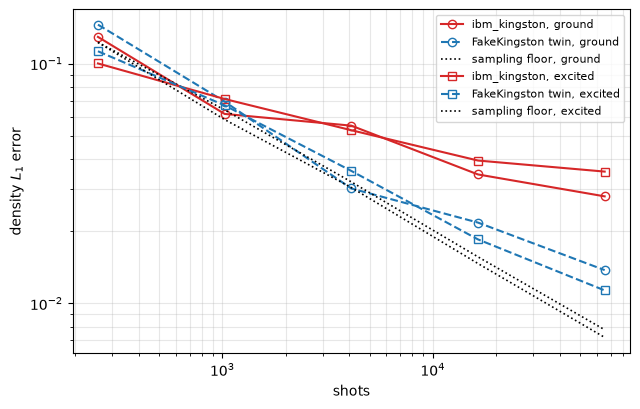

In [8]:
ri = json.load(open(f'{H}/blockI_results.json'))
levels = ri['levels']
get = lambda src, s, key: dict(ri[src][str(s)])[key]

# the finite-sampling floor: resample the exact distribution at the same shot counts
p1 = problem_1d(5)
p1e = problem_1d(5, 1.0)
rng = np.random.default_rng(0)
floor = {}
for key, ref in [('l1_g', np.abs(p1.ground)**2), ('l1_e', np.abs(p1e.excited1)**2)]:
    floor[key] = [np.mean([0.5*np.abs(rng.multinomial(s, ref)/s - ref).sum()
                           for _ in range(40)]) for s in levels]

plt.figure(figsize=(6.5, 4.2))
for key, st in [('l1_g', 'ground'), ('l1_e', 'excited')]:
    mk = 'o' if key == 'l1_g' else 's'
    plt.loglog(levels, [get('hw', s, key) for s in levels], mk + '-', color='#d62728',
               mfc='none', label=f'ibm_kingston, {st}')
    plt.loglog(levels, [get('twin', s, key) for s in levels], mk + '--', color='#1f77b4',
               mfc='none', label=f'FakeKingston twin, {st}')
    plt.loglog(levels, floor[key], ':', color='k', lw=1.2,
               label=f'sampling floor, {st}')
plt.xlabel('shots'); plt.ylabel(r'density $L_1$ error')
plt.grid(alpha=.3, which='both'); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()

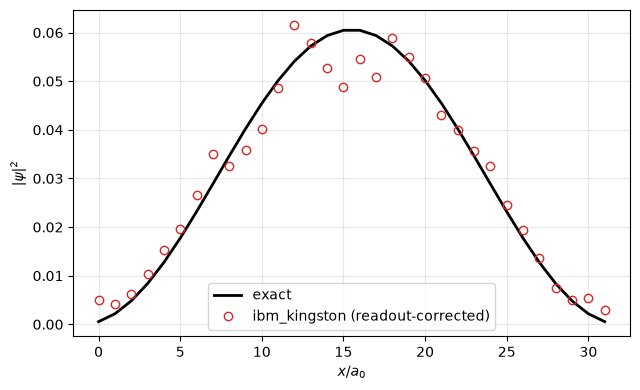

In [9]:
# the 1-D densities the device actually returned, at the largest shot count
rho_g = np.loadtxt(f'{H}/blockB_density_hw.csv', delimiter=',', skiprows=1)
p1 = problem_1d(5)
plt.figure(figsize=(6.5, 4))
plt.plot(np.arange(32), np.abs(p1.ground)**2, 'k-', lw=2, label='exact')
plt.plot(np.arange(32), rho_g, 'o', color='#d62728', mfc='none',
         label='ibm_kingston (readout-corrected)')
plt.xlabel(r'$x/a_0$'); plt.ylabel(r'$|\psi|^2$')
plt.grid(alpha=.3); plt.legend(); plt.tight_layout(); plt.show()

### **Parameter Provenance**

The same state prepared at parameters from four training provenances, in one job.

In [10]:
rj = json.load(open(f'{H}/blockJ_results.json'))
order = ['noiseless', 'kingston_mitRO', 'sherbrooke', 'kingston_raw']
print(f"{'training provenance':<20}{'intrinsic eps_tr':>18}{'device L1':>12}{'twin L1':>10}")
for k in order:
    r = rj[k]
    print(f"{k:<20}{r['state_trace']:>18.4f}{r['hw_l1']:>12.4f}{r['twin_l1']:>10.4f}")

training provenance   intrinsic eps_tr   device L1   twin L1
noiseless                       0.0010      0.0286    0.0153
kingston_mitRO                  0.0222      0.0324    0.0133
sherbrooke                      0.0565      0.0616    0.0496
kingston_raw                    0.0940      0.0827    0.0775


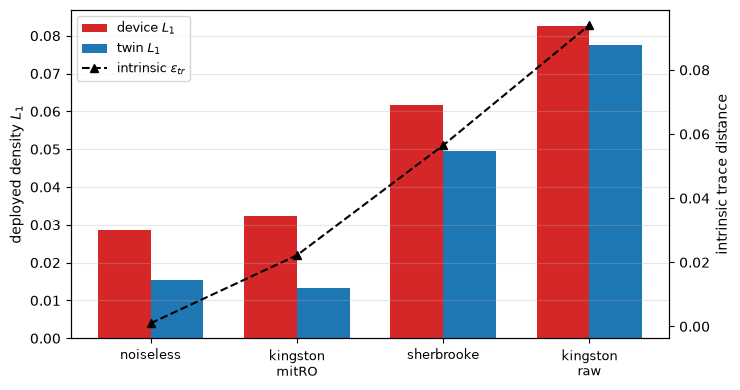

In [11]:
xs = np.arange(len(order)); w = 0.36
fig, ax1 = plt.subplots(figsize=(7.5, 4))
ax1.bar(xs - w/2, [rj[k]['hw_l1'] for k in order], w, color='#d62728', label='device $L_1$')
ax1.bar(xs + w/2, [rj[k]['twin_l1'] for k in order], w, color='#1f77b4', label='twin $L_1$')
ax1.set_xticks(xs); ax1.set_xticklabels([k.replace('_', '\n') for k in order], fontsize=9)
ax1.set_ylabel(r'deployed density $L_1$'); ax1.grid(alpha=.3, axis='y')
ax2 = ax1.twinx()
ax2.plot(xs, [rj[k]['state_trace'] for k in order], 'k^--', label=r'intrinsic $\varepsilon_{tr}$')
ax2.set_ylabel(r'intrinsic trace distance')
h1, l1_ = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1_ + l2, fontsize=9, loc='upper left')
plt.tight_layout(); plt.show()